In [209]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from matplotlib import pyplot as plt
import sys
import matplotlib.pyplot as plt
from pathlib import Path

# add repo root so swiss_roll_models can be imported from anywhere
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "swiss_roll_models").exists():
        sys.path.insert(0, str(p))
        break

from swiss_roll_models.environment.dataset import generate_swiss_roll
from swiss_roll_models.environment.hilbert_distance import hilbert_analysis as hda

# positive linear model = softplus(theta) ∈ R^D_{>0}
class PositiveLinear(nn.Module):
    def __init__(self, D):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(D))  # trainable parameters
    def forward(self, X):
        w = F.softplus(self.theta)
        return X @ w

    def positive_params_vector(self):
        # Return the current positive parameter vector for Hilbert distance calculation
        return F.softplus(self.theta).detach().clone()


In [ ]:
def run_experiment_on_subset(
    X_full : torch.Tensor,
    y_full : torch.Tensor,
    n: int,
    num_epochs : int = 500,
    lr : float = 1e-2,
    l2_reg : float = 1e-3,
    device : str = 'cuda',
    seed : int = 114514,
) -> dict:
        
    """
    Run training on a random subset of size n from (X_full, y_full).
        Args:
            X_full: Full input data tensor of shape (N, D).
            y_full: Full target data tensor of shape (N,).
            n: Size of the subset to sample for training.
            num_epochs: Number of training epochs.
            lr: Learning rate for SGD.
            l2_reg: L2 regularization coefficient.
            device: Device to run the computations on ("cuda" or "cpu").

        Returns:
            A dictionary containing:
                - 'n': The subset size used.
                - 'loss_traj': List of loss values per epoch.
                - 'param_traj': List of parameter vectors per epoch.
                - 'w_star': Final learned positive parameter vector.
    """

    N, D = X_full.shape
    idx = torch.randperm(N, device=device)[:n]
    X = X_full[idx]
    y = y_full[idx]
    torch.manual_seed(seed)
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=n, shuffle=False)  # full-batch

    model = PositiveLinear(D).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    param_traj = []
    loss_traj = []

    for epoch in range(num_epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()

            # 1. prediction
            y_pred = model(batch_X)

            # 2. MSE part
            mse = F.mse_loss(y_pred, batch_y)

            # 3. L2 regularization: regularize w = softplus(theta) in the positive cone
            w = F.softplus(model.theta)
            l2 = (w ** 2).sum()

            # 4. Total loss = mse + λ ||w||^2
            loss = mse + l2_reg * l2

            loss.backward()
            optimizer.step()

        loss_traj.append(loss.item())
        param_traj.append(model.positive_params_vector().cpu())

    w_star = param_traj[-1]

    prev = param_traj[0]
    return {
        "n": n,
        "loss_traj": loss_traj,
        "param_traj": param_traj,
        "w_star": w_star,
    }


In [211]:

from matplotlib.ticker import MaxNLocator


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ----- Generate Swiss roll -----
N = 50_000
D = 4096
X_full, y_full, u, v = generate_swiss_roll(
    n_samples=N,
    D=D,
    noise=100,
    device=device,
)
print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")

# ----- Different small sample sizes -----
n_list = [50, 100, 200, 500]
num_epochs = 500
lr = 1e-3
l2_list = [0,1e-3,1e-2,1e-1]
l2 = l2_list[0]
first_20s=[]
other_20s=[]
# all_results[n][l2_reg] = corresponding experiment results
all_results = {}
n=100
names=[]
for n in n_list:
    all_results[n] = {}
    print(f"\n================ n = {n} ================")
    title = f"n={n} and l2_reg={l2}"
    print(f"\n--- Running experiment as {title} ---")
    res = run_experiment_on_subset(
        X_full,
        y_full,
        n=n,
        num_epochs=num_epochs,
        lr=lr,
        l2_reg= l2,
        device=device,
    )
    names.append(title)
    all_results[n][l2] = res  
    w = res['w_star']
    first_20_param = res['param_traj'][:15]
    other_20_param = res['param_traj'][15:len(res['param_traj'])]
    hdist_traj=hda.analysis_distance_on_cone(param_traj=first_20_param, w_star=first_20_param[-1])
    hdist_traj2=hda.analysis_distance_on_cone(param_traj=other_20_param, w_star=other_20_param[-1])
    hbt_initial=hdist_traj['hilbert_to_final']
    hbt_initial2=hdist_traj2['hilbert_to_final']
    first_20 = hbt_initial[:20]
    other_20 = hbt_initial2
    first_20s.append(first_20)
    other_20s.append(other_20)
    



Using device: cuda
Full dataset: X=torch.Size([50000, 4096]), y=torch.Size([50000])

================ n = 50 ================

--- Running experiment as n=50 and l2_reg=0 ---

================ n = 100 ================

--- Running experiment as n=100 and l2_reg=0 ---

================ n = 200 ================

--- Running experiment as n=200 and l2_reg=0 ---

================ n = 500 ================

--- Running experiment as n=500 and l2_reg=0 ---


<Figure size 800x600 with 0 Axes>

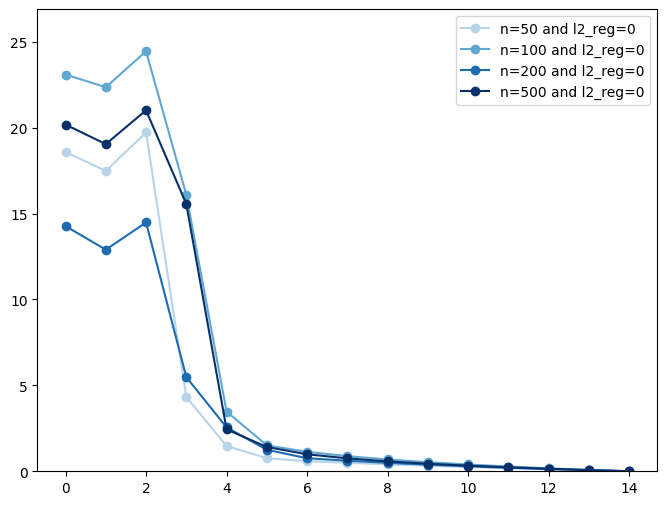

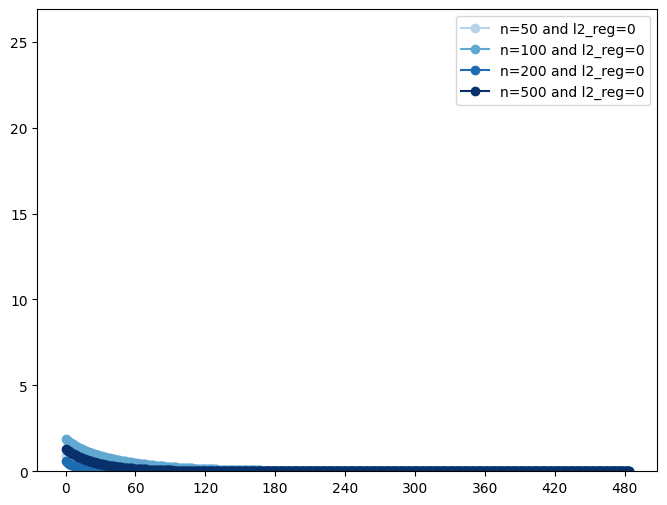

In [212]:
fig = plt.figure(figsize=(8, 6))
y_min = 0
y_max = max(
    max(max(group) for group in first_20s),
    max(max(group) for group in other_20s)
) * 1.1

import matplotlib.cm as cm
plt.figure(figsize=(8, 6)) 
plt.ylim(y_min, y_max)
plt.xscale('linear')
plt.yscale('linear')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
num_groups = len(first_20s)

start, end = 0.3, 1.0
colors = cm.Blues([start + (end - start) * i / (num_groups - 1) for i in range(num_groups)])
for i, first_20 in enumerate(first_20s):

    plt.plot(range(len(first_20)), first_20, marker='o', color=colors[i],label=names[i])

plt.legend()
plt.show()


plt.figure(figsize=(8, 6))
plt.ylim(y_min, y_max)
plt.xscale('linear')
plt.yscale('linear')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
for i, other_20 in enumerate(other_20s):
    plt.plot(range(len(other_20)), other_20, marker='o', color=colors[i],label=names[i])
plt.legend()
plt.show()